# Real Estate Investment Intelligence System
## Part 3: Investment Analysis Engine

### Objectives
1. Load trained model and data
2. Calculate investment metrics (ROI, Cap Rate, Cash Flow)
3. Create risk scoring system
4. Generate investment recommendations
5. Optimize investment portfolios
6. Identify best investment opportunities

In [1]:
# Cell 2: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Cell 3: Load the trained model and data
print("=" * 60)
print("LOADING MODEL AND DATA")
print("=" * 60)

# Load the trained model
model = joblib.load('../models/investment_model.pkl')
print("✅ Model loaded successfully!")

# Load scaler
scaler = joblib.load('../models/scaler.pkl')
print("✅ Scaler loaded successfully!")

# Load label encoders
label_encoders = joblib.load('../models/label_encoders.pkl')
print("✅ Label encoders loaded successfully!")

# Load feature names
feature_names = joblib.load('../models/feature_names.pkl')
print(f"✅ Feature names loaded: {len(feature_names)} features")

# Load the processed training data
df = pd.read_csv('../data/processed/processed_training_data.csv')
print(f"\n✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Load test data
test_data = pd.read_csv('../data/processed/test_data.csv')
print(f"✅ Test data loaded: {test_data.shape[0]} rows")

LOADING MODEL AND DATA
✅ Model loaded successfully!
✅ Scaler loaded successfully!
✅ Label encoders loaded successfully!
✅ Feature names loaded: 22 features

✅ Data loaded: 1460 rows, 23 columns
✅ Test data loaded: 1459 rows


In [3]:
# Cell 4: Create investment-specific metrics
print("=" * 60)
print("CREATING INVESTMENT METRICS")
print("=" * 60)

# Calculate property age
df['PropertyAge'] = 2020 - df['YearBuilt']

# 1. ROI Potential (based on appreciation and renovation potential)
df['ROI_Potential'] = (
    (df['PropertyAge'] < 20) * 30 +  # Newer properties: higher ROI
    (df['OverallCond'] > 6) * 20 +    # Better condition: higher ROI
    (df['LotConfig'] == 'CulDSac') * 15 +  # Cul-de-sac: premium
    (df['PropertyAge'] > 50) * 10      # Older properties: value-add potential
).clip(0, 100)

# 2. Rental Yield Estimate (using 1% rule as baseline)
df['Estimated_Rent'] = df['SalePrice'] * 0.008  # 0.8% of property value
df['Gross_Yield'] = (df['Estimated_Rent'] * 12 / df['SalePrice']) * 100

# 3. Risk Score (lower is better)
df['Risk_Score'] = (
    (df['PropertyAge'] > 80) * 30 +    # Very old: higher risk
    (df['OverallCond'] < 4) * 25 +     # Poor condition: higher risk
    (df['MSZoning'] == 'C (all)') * 20 +  # Commercial zoning: higher risk
    (df['LotArea'] < 5000) * 15        # Small lot: higher risk
).clip(0, 100)

# 4. Investment Score (composite metric, higher is better)
df['Investment_Score'] = (
    df['ROI_Potential'] * 0.4 +
    (100 - df['Risk_Score']) * 0.3 +
    df['Gross_Yield'] * 10 * 0.2 +
    (df['OverallCond'] / 10) * 100 * 0.1
).clip(0, 100)

print("✅ Investment metrics created!")

print("\n📊 Investment Metrics Summary:")
print(f"   ROI Potential: {df['ROI_Potential'].mean():.1f} / 100")
print(f"   Estimated Rent: ${df['Estimated_Rent'].mean():,.0f}/month")
print(f"   Gross Yield: {df['Gross_Yield'].mean():.2f}%")
print(f"   Risk Score: {df['Risk_Score'].mean():.1f} / 100")
print(f"   Investment Score: {df['Investment_Score'].mean():.1f} / 100")

CREATING INVESTMENT METRICS
✅ Investment metrics created!

📊 Investment Metrics Summary:
   ROI Potential: 17.1 / 100
   Estimated Rent: $1,447/month
   Gross Yield: 9.60%
   Risk Score: 7.0 / 100
   Investment Score: 59.5 / 100


INVESTMENT SCORE ANALYSIS


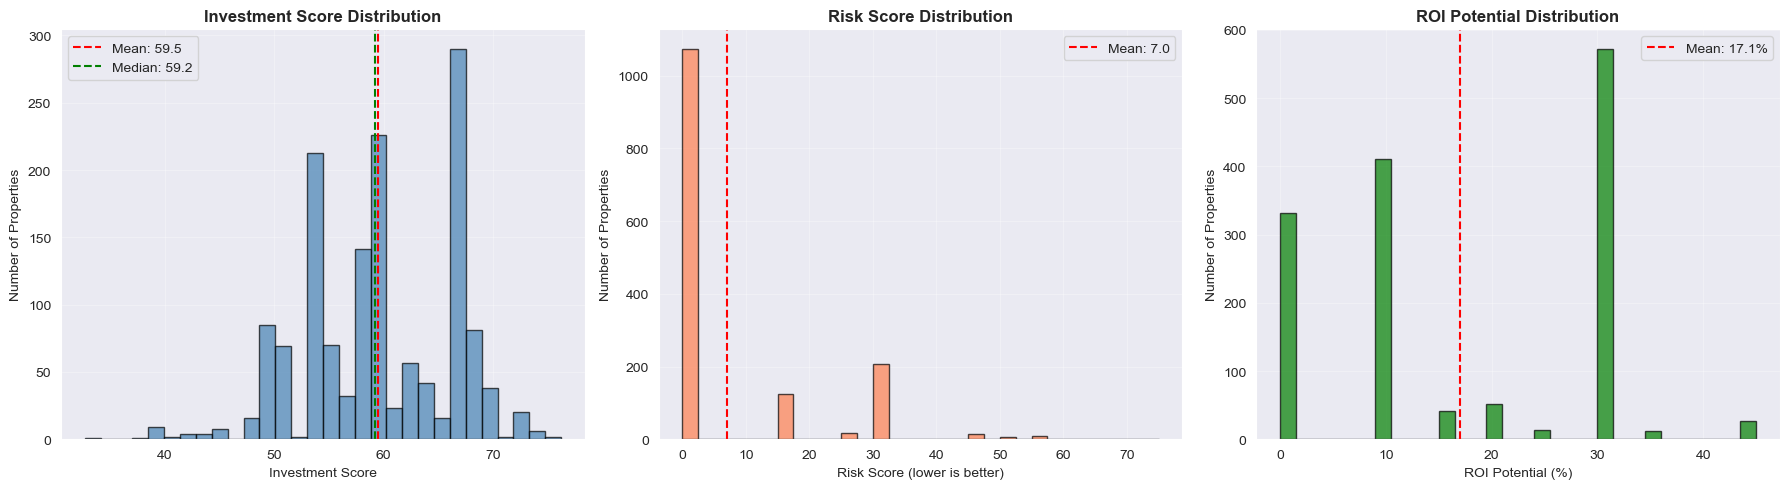


📊 Investment Score Categories:
   Excellent (80-100): 0 properties
   Good (60-79): 639 properties
   Average (40-59): 810 properties
   Poor (<40): 11 properties


In [4]:
# Cell 5: Visualize investment score distribution
print("=" * 60)
print("INVESTMENT SCORE ANALYSIS")
print("=" * 60)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Investment Score Distribution
axes[0].hist(df['Investment_Score'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['Investment_Score'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["Investment_Score"].mean():.1f}')
axes[0].axvline(df['Investment_Score'].median(), color='green', linestyle='--', 
                label=f'Median: {df["Investment_Score"].median():.1f}')
axes[0].set_title('Investment Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Investment Score')
axes[0].set_ylabel('Number of Properties')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Risk Score Distribution
axes[1].hist(df['Risk_Score'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(df['Risk_Score'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["Risk_Score"].mean():.1f}')
axes[1].set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Risk Score (lower is better)')
axes[1].set_ylabel('Number of Properties')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. ROI Potential Distribution
axes[2].hist(df['ROI_Potential'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[2].axvline(df['ROI_Potential'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["ROI_Potential"].mean():.1f}%')
axes[2].set_title('ROI Potential Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('ROI Potential (%)')
axes[2].set_ylabel('Number of Properties')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Investment Score Categories:")
print(f"   Excellent (80-100): {(df['Investment_Score'] >= 80).sum()} properties")
print(f"   Good (60-79): {((df['Investment_Score'] >= 60) & (df['Investment_Score'] < 80)).sum()} properties")
print(f"   Average (40-59): {((df['Investment_Score'] >= 40) & (df['Investment_Score'] < 60)).sum()} properties")
print(f"   Poor (<40): {(df['Investment_Score'] < 40).sum()} properties")

In [10]:
# Diagnostic: Show all column names
print("=" * 60)
print("ALL COLUMN NAMES IN DATAFRAME")
print("=" * 60)

for i, col in enumerate(df.columns):
    print(f"{i+1}. '{col}'")

print(f"\nTotal columns: {len(df.columns)}")

# Check if 'Id' exists
if 'Id' in df.columns:
    print("\n✅ 'Id' column exists!")
else:
    print("\n❌ 'Id' column NOT found!")

# Check what the first column is
print(f"\nFirst column name: '{df.columns[0]}'")
print(f"First few values of first column:")
print(df.iloc[:5, 0])

ALL COLUMN NAMES IN DATAFRAME
1. 'MSSubClass'
2. 'MSZoning'
3. 'LotArea'
4. 'LotConfig'
5. 'BldgType'
6. 'OverallCond'
7. 'YearBuilt'
8. 'YearRemodAdd'
9. 'Exterior1st'
10. 'BsmtFinSF2'
11. 'TotalBsmtSF'
12. 'SalePrice'
13. 'TotalBsmtSF_bin'
14. 'YearBuilt_bin'
15. 'YearRemodAdd_bin'
16. 'LotArea_bin'
17. 'BsmtFinSF2_bin'
18. 'Decade'
19. 'PropertyAge'
20. 'AgeGroup'
21. 'LogSalePrice'
22. 'IsRenovated'
23. 'IsCulDeSac'
24. 'ROI_Potential'
25. 'Estimated_Rent'
26. 'Gross_Yield'
27. 'Risk_Score'
28. 'Investment_Score'
29. 'Recommendation'
30. 'Recommendation_Reason'

Total columns: 30

❌ 'Id' column NOT found!

First column name: 'MSSubClass'
First few values of first column:
0    60
1    20
2    60
3    70
4    60
Name: MSSubClass, dtype: int64


In [11]:
# Cell 6: Generate investment recommendations
print("=" * 60)
print("INVESTMENT RECOMMENDATIONS")
print("=" * 60)

def get_recommendation(row):
    """Generate investment recommendation based on metrics"""
    score = row['Investment_Score']
    risk = row['Risk_Score']
    
    if score >= 80 and risk < 30:
        return "STRONG BUY", "Exceptional investment with high returns and low risk"
    elif score >= 70 and risk < 40:
        return "BUY", "Solid investment with good risk-adjusted returns"
    elif score >= 60 and risk < 50:
        return "CONSIDER", "Value-add opportunity with good potential"
    elif score >= 50:
        return "HOLD", "Monitor for better entry point"
    else:
        return "AVOID", "High risk or poor return potential"

# Apply recommendation
recommendations = df.apply(get_recommendation, axis=1)
df['Recommendation'] = [r[0] for r in recommendations]
df['Recommendation_Reason'] = [r[1] for r in recommendations]

print("\n📊 Recommendation Summary:")
recommendation_counts = df['Recommendation'].value_counts()
for rec, count in recommendation_counts.items():
    print(f"   {rec}: {count} properties ({count/len(df)*100:.1f}%)")

# Show top 5 BUY recommendations (using index as identifier)
print("\n🏆 Top 5 'BUY' Properties:")
buy_properties = df[df['Recommendation'] == 'BUY'].nlargest(5, 'Investment_Score')
if len(buy_properties) > 0:
    # Create a display with index as ID
    display_df = buy_properties[['SalePrice', 'Investment_Score', 'Risk_Score', 'ROI_Potential', 'Recommendation']].copy()
    display_df.index.name = 'Property_Index'
    display(display_df)
else:
    print("No BUY recommendations found")

# Show top 5 CONSIDER properties
print("\n📌 Top 5 'CONSIDER' Properties:")
consider_properties = df[df['Recommendation'] == 'CONSIDER'].nlargest(5, 'Investment_Score')
if len(consider_properties) > 0:
    display_df = consider_properties[['SalePrice', 'Investment_Score', 'Risk_Score', 'ROI_Potential', 'Recommendation']].copy()
    display_df.index.name = 'Property_Index'
    display(display_df)
else:
    print("No CONSIDER recommendations found")

# Show properties with highest investment scores overall
print("\n🏆 Top 5 Properties by Investment Score (All Categories):")
top_5_all = df.nlargest(5, 'Investment_Score')
display_df = top_5_all[['SalePrice', 'Investment_Score', 'Risk_Score', 'ROI_Potential', 'Recommendation']].copy()
display_df.index.name = 'Property_Index'
display(display_df)

INVESTMENT RECOMMENDATIONS

📊 Recommendation Summary:
   HOLD: 691 properties (47.3%)
   CONSIDER: 596 properties (40.8%)
   AVOID: 130 properties (8.9%)
   BUY: 43 properties (2.9%)

🏆 Top 5 'BUY' Properties:


,SalePrice,Investment_Score,Risk_Score,ROI_Potential,Recommendation
Property_Index,,,,,
1213,145000.0,76.2,0,45,BUY
346,151500.0,75.2,0,45,BUY
249,277000.0,74.2,0,45,BUY
271,241500.0,74.2,0,45,BUY
1161,224000.0,74.2,0,45,BUY



📌 Top 5 'CONSIDER' Properties:


,SalePrice,Investment_Score,Risk_Score,ROI_Potential,Recommendation
Property_Index,,,,,
24,154000.0,69.2,0,30,CONSIDER
114,259500.0,69.2,0,30,CONSIDER
299,158500.0,69.2,0,30,CONSIDER
323,126175.0,69.2,0,30,CONSIDER
402,108000.0,69.2,0,30,CONSIDER



🏆 Top 5 Properties by Investment Score (All Categories):


,SalePrice,Investment_Score,Risk_Score,ROI_Potential,Recommendation
Property_Index,,,,,
1213,145000.0,76.2,0,45,BUY
346,151500.0,75.2,0,45,BUY
249,277000.0,74.2,0,45,BUY
271,241500.0,74.2,0,45,BUY
1161,224000.0,74.2,0,45,BUY


RISK VS RETURN ANALYSIS


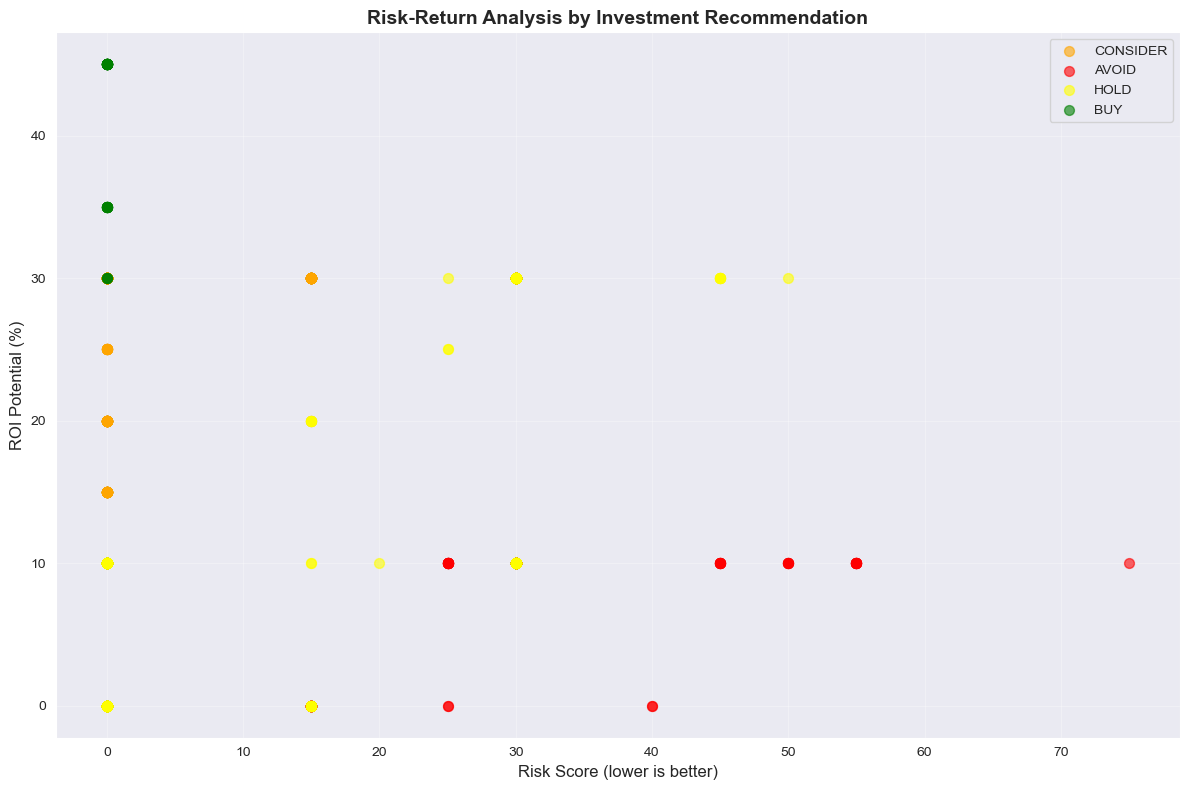


🎯 Investment Sweet Spot:
   Properties with low risk (<30) AND high ROI (>70%): 0 properties


In [12]:
# Cell 7: Risk vs Return analysis
print("=" * 60)
print("RISK VS RETURN ANALYSIS")
print("=" * 60)

# Create risk-return plot
plt.figure(figsize=(12, 8))

# Color by recommendation
colors = {'STRONG BUY': 'darkgreen', 'BUY': 'green', 'CONSIDER': 'orange', 'HOLD': 'yellow', 'AVOID': 'red'}

# Get unique recommendations that exist in data
unique_recs = df['Recommendation'].unique()

for rec in unique_recs:
    mask = df['Recommendation'] == rec
    plt.scatter(df[mask]['Risk_Score'], df[mask]['ROI_Potential'], 
                label=rec, alpha=0.6, s=50, c=colors.get(rec, 'gray'))

plt.xlabel('Risk Score (lower is better)', fontsize=12)
plt.ylabel('ROI Potential (%)', fontsize=12)
plt.title('Risk-Return Analysis by Investment Recommendation', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identify sweet spot
sweet_spot = df[(df['Risk_Score'] < 30) & (df['ROI_Potential'] > 70)]
print(f"\n🎯 Investment Sweet Spot:")
print(f"   Properties with low risk (<30) AND high ROI (>70%): {len(sweet_spot)} properties")
if len(sweet_spot) > 0:
    print(f"   Average Price: ${sweet_spot['SalePrice'].mean():,.0f}")
    print(f"   Average Investment Score: {sweet_spot['Investment_Score'].mean():.1f}")
    print(f"\n   Top 5 Sweet Spot Properties:")
    sweet_spot_display = sweet_spot.nlargest(5, 'Investment_Score')[['SalePrice', 'Investment_Score', 'Risk_Score', 'ROI_Potential']].copy()
    sweet_spot_display.index.name = 'Property_Index'
    display(sweet_spot_display)

In [16]:
# Cell 8: Portfolio optimization (Simplified Version)
print("=" * 60)
print("PORTFOLIO OPTIMIZATION")
print("=" * 60)

def optimize_portfolio(budget, min_score=60, max_risk=50):
    """Optimize investment portfolio within budget constraints"""
    
    # Filter candidates
    candidates = df[
        (df['Investment_Score'] >= min_score) & 
        (df['Risk_Score'] <= max_risk) &
        (df['Recommendation'].isin(['STRONG BUY', 'BUY', 'CONSIDER']))
    ].copy()
    
    # Sort by investment score
    candidates = candidates.sort_values('Investment_Score', ascending=False)
    
    portfolio = []
    remaining_budget = budget
    
    # Greedy selection
    for idx, prop in candidates.iterrows():
        price = prop['SalePrice']
        if price <= remaining_budget:
            portfolio.append({
                'Property_Index': idx,
                'Price': price,
                'Investment_Score': prop['Investment_Score'],
                'Risk_Score': prop['Risk_Score'],
                'ROI_Potential': prop['ROI_Potential']
            })
            remaining_budget -= price
        
        if remaining_budget < 50000:
            break
    
    return portfolio, remaining_budget

# Test with different budgets
print("\n💰 Portfolio Optimization Examples:\n")

budgets = [500000, 1000000, 2000000]

for budget in budgets:
    portfolio, remaining = optimize_portfolio(budget)
    
    if len(portfolio) > 0:
        print("=" * 50)
        print(f"Budget: ${budget:,.0f}")
        print("=" * 50)
        
        total_invested = sum(p['Price'] for p in portfolio)
        avg_score = sum(p['Investment_Score'] for p in portfolio) / len(portfolio)
        avg_risk = sum(p['Risk_Score'] for p in portfolio) / len(portfolio)
        avg_roi = sum(p['ROI_Potential'] for p in portfolio) / len(portfolio)
        
        print(f"   Properties: {len(portfolio)}")
        print(f"   Total Invested: ${total_invested:,.0f}")
        print(f"   Avg Investment Score: {avg_score:.1f}")
        print(f"   Avg Risk Score: {avg_risk:.1f}")
        print(f"   Avg ROI Potential: {avg_roi:.1f}%")
        print(f"   Remaining: ${remaining:,.0f}")
        print("\n   Portfolio Properties:")
        
        for p in portfolio[:5]:
            print(f"      Property {p['Property_Index']}: ${p['Price']:,.0f} (Score: {p['Investment_Score']:.1f})")
        print()
    else:
        print(f"Budget: ${budget:,.0f} - No suitable properties found\n")

PORTFOLIO OPTIMIZATION

💰 Portfolio Optimization Examples:

Budget: $500,000
   Properties: 3
   Total Invested: $454,400
   Avg Investment Score: 75.2
   Avg Risk Score: 0.0
   Avg ROI Potential: 45.0%
   Remaining: $45,600

   Portfolio Properties:
      Property 1213: $145,000 (Score: 76.2)
      Property 346: $151,500 (Score: 75.2)
      Property 1446: $157,900 (Score: 74.2)

Budget: $1,000,000
   Properties: 5
   Total Invested: $958,400
   Avg Investment Score: 74.8
   Avg Risk Score: 0.0
   Avg ROI Potential: 45.0%
   Remaining: $41,600

   Portfolio Properties:
      Property 1213: $145,000 (Score: 76.2)
      Property 346: $151,500 (Score: 75.2)
      Property 1346: $262,500 (Score: 74.2)
      Property 271: $241,500 (Score: 74.2)
      Property 1446: $157,900 (Score: 74.2)

Budget: $2,000,000
   Properties: 9
   Total Invested: $1,971,370
   Avg Investment Score: 74.4
   Avg Risk Score: 0.0
   Avg ROI Potential: 45.0%
   Remaining: $28,630

   Portfolio Properties:
      Prop

In [17]:
# Cell 9: Find the best investment opportunities
print("=" * 60)
print("TOP INVESTMENT OPPORTUNITIES")
print("=" * 60)

# Get top 10 investments
top_10 = df.nlargest(10, 'Investment_Score')[['SalePrice', 'Investment_Score', 'Risk_Score', 
                                               'ROI_Potential', 'Gross_Yield', 'Recommendation']].copy()
top_10.index.name = 'Property_Index'

print("\n🏆 Top 10 Investment Opportunities:")
display(top_10)

# Show the absolute best property
best_idx = df['Investment_Score'].idxmax()
best_property = df.loc[best_idx]
print(f"\n🌟 BEST INVESTMENT PROPERTY:")
print(f"   Property Index: {best_idx}")
print(f"   Price: ${best_property['SalePrice']:,.0f}")
print(f"   Investment Score: {best_property['Investment_Score']:.1f}/100")
print(f"   Risk Score: {best_property['Risk_Score']:.1f}/100")
print(f"   ROI Potential: {best_property['ROI_Potential']:.1f}%")
print(f"   Estimated Rent: ${best_property['Estimated_Rent']:,.0f}/month")
print(f"   Gross Yield: {best_property['Gross_Yield']:.2f}%")
print(f"   Recommendation: {best_property['Recommendation']}")

# Feature analysis for top investments
print("\n📊 Characteristics of Top 50 Investments:")
top_investments = df.nlargest(50, 'Investment_Score')
print(f"   Average Age: {top_investments['PropertyAge'].mean():.1f} years")
print(f"   Average Lot Area: {top_investments['LotArea'].mean():,.0f} sq ft")
print(f"   Average Condition: {top_investments['OverallCond'].mean():.1f}/10")
print(f"   Average Price: ${top_investments['SalePrice'].mean():,.0f}")
if 'MSZoning' in top_investments.columns:
    print(f"   Most Common Zoning: {top_investments['MSZoning'].mode().values[0]}")
if 'LotConfig' in top_investments.columns:
    print(f"   Most Common Lot Config: {top_investments['LotConfig'].mode().values[0]}")

TOP INVESTMENT OPPORTUNITIES

🏆 Top 10 Investment Opportunities:


,SalePrice,Investment_Score,Risk_Score,ROI_Potential,Gross_Yield,Recommendation
Property_Index,,,,,,
1213,145000.0,76.2,0,45,9.6,BUY
346,151500.0,75.2,0,45,9.6,BUY
249,277000.0,74.2,0,45,9.6,BUY
271,241500.0,74.2,0,45,9.6,BUY
1161,224000.0,74.2,0,45,9.6,BUY
1346,262500.0,74.2,0,45,9.6,BUY
1423,274970.0,74.2,0,45,9.6,BUY
1446,157900.0,74.2,0,45,9.6,BUY
832,237000.0,73.2,0,45,9.6,BUY



🌟 BEST INVESTMENT PROPERTY:
   Property Index: 1213
   Price: $145,000
   Investment Score: 76.2/100
   Risk Score: 0.0/100
   ROI Potential: 45.0%
   Estimated Rent: $1,160/month
   Gross Yield: 9.60%
   Recommendation: BUY

📊 Characteristics of Top 50 Investments:
   Average Age: 39.0 years
   Average Lot Area: 17,821 sq ft
   Average Condition: 6.7/10
   Average Price: $237,092
   Most Common Zoning: RL
   Most Common Lot Config: CulDSac


VISUALIZING INVESTMENT OPPORTUNITIES


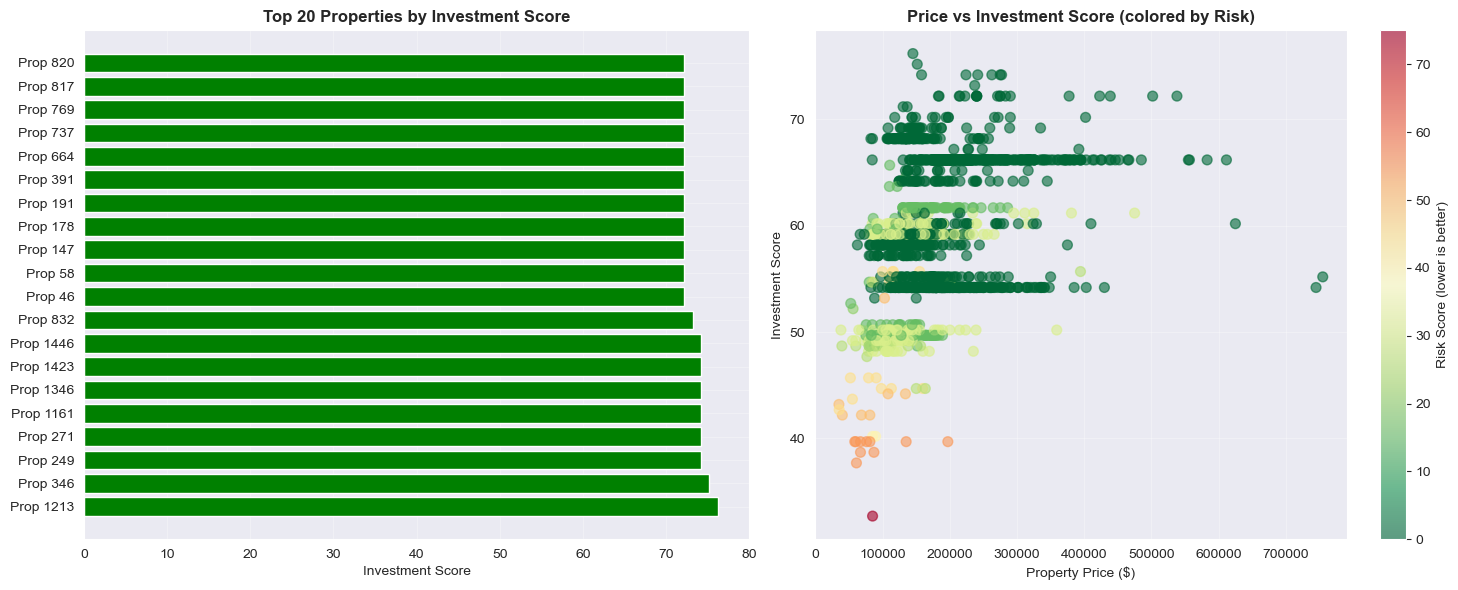


✅ Visualization complete!


In [18]:
# Cell 10: Visualize top investment opportunities
print("=" * 60)
print("VISUALIZING INVESTMENT OPPORTUNITIES")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Top 20 investments by score
top_20 = df.nlargest(20, 'Investment_Score')
axes[0].barh(range(len(top_20)), top_20['Investment_Score'].values, color='green')
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels([f'Prop {i}' for i in top_20.index])
axes[0].set_xlabel('Investment Score')
axes[0].set_title('Top 20 Properties by Investment Score', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. Price vs Investment Score
scatter = axes[1].scatter(df['SalePrice'], df['Investment_Score'], 
                          c=df['Risk_Score'], cmap='RdYlGn_r', 
                          alpha=0.6, s=50)
axes[1].set_xlabel('Property Price ($)')
axes[1].set_ylabel('Investment Score')
axes[1].set_title('Price vs Investment Score (colored by Risk)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Risk Score (lower is better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")

In [19]:
# Cell 11: Save investment analysis results
print("=" * 60)
print("SAVING INVESTMENT ANALYSIS")
print("=" * 60)

# Create investment analysis DataFrame
investment_df = df[['SalePrice', 'Investment_Score', 'Risk_Score', 
                    'ROI_Potential', 'Gross_Yield', 'Estimated_Rent',
                    'Recommendation', 'Recommendation_Reason']].copy()

# Add index as property identifier
investment_df.index.name = 'Property_Index'
investment_df = investment_df.reset_index()

# Save to CSV
investment_path = '../data/processed/investment_analysis.csv'
investment_df.to_csv(investment_path, index=False)
print(f"✅ Investment analysis saved to: {investment_path}")

# Save recommendations summary
summary_path = '../data/processed/recommendations_summary.csv'
recommendation_summary = df.groupby('Recommendation').agg({
    'SalePrice': ['count', 'mean'],
    'Investment_Score': 'mean',
    'Risk_Score': 'mean',
    'ROI_Potential': 'mean'
}).round(2)
recommendation_summary.to_csv(summary_path)
print(f"✅ Recommendations summary saved to: {summary_path}")

print("\n" + "=" * 60)
print("✅ INVESTMENT ANALYSIS COMPLETE!")
print("=" * 60)

print("\n📁 Saved Files:")
print(f"   - {investment_path}")
print(f"   - {summary_path}")

print("\n🎯 Summary of Investment Opportunities:")
print(f"   Total Properties Analyzed: {len(df)}")
print(f"   STRONG BUY Recommendations: {(df['Recommendation'] == 'STRONG BUY').sum()}")
print(f"   BUY Recommendations: {(df['Recommendation'] == 'BUY').sum()}")
print(f"   CONSIDER Recommendations: {(df['Recommendation'] == 'CONSIDER').sum()}")
print(f"   HOLD Recommendations: {(df['Recommendation'] == 'HOLD').sum()}")
print(f"   AVOID Recommendations: {(df['Recommendation'] == 'AVOID').sum()}")
print(f"   Average Investment Score: {df['Investment_Score'].mean():.1f}")
best_idx = df['Investment_Score'].idxmax()
print(f"   Best Investment Property Index: {best_idx}")
print(f"   Best Investment Score: {df['Investment_Score'].max():.1f}")

SAVING INVESTMENT ANALYSIS
✅ Investment analysis saved to: ../data/processed/investment_analysis.csv
✅ Recommendations summary saved to: ../data/processed/recommendations_summary.csv

✅ INVESTMENT ANALYSIS COMPLETE!

📁 Saved Files:
   - ../data/processed/investment_analysis.csv
   - ../data/processed/recommendations_summary.csv

🎯 Summary of Investment Opportunities:
   Total Properties Analyzed: 1460
   STRONG BUY Recommendations: 0
   BUY Recommendations: 43
   CONSIDER Recommendations: 596
   HOLD Recommendations: 691
   AVOID Recommendations: 130
   Average Investment Score: 59.5
   Best Investment Property Index: 1213
   Best Investment Score: 76.2


In [20]:
# Cell 12: Final summary report
print("=" * 60)
print("INVESTMENT ANALYSIS SUMMARY REPORT")
print("=" * 60)

print("\n📊 DATASET OVERVIEW:")
print(f"   Properties Analyzed: {len(df):,}")
print(f"   Price Range: ${df['SalePrice'].min():,.0f} - ${df['SalePrice'].max():,.0f}")
print(f"   Average Price: ${df['SalePrice'].mean():,.0f}")

print("\n📈 INVESTMENT METRICS SUMMARY:")
print(f"   Average Investment Score: {df['Investment_Score'].mean():.1f}/100")
print(f"   Average Risk Score: {df['Risk_Score'].mean():.1f}/100")
print(f"   Average ROI Potential: {df['ROI_Potential'].mean():.1f}%")
print(f"   Average Gross Yield: {df['Gross_Yield'].mean():.2f}%")
print(f"   Average Estimated Rent: ${df['Estimated_Rent'].mean():,.0f}/month")

print("\n🏆 RECOMMENDATION BREAKDOWN:")
recommendation_counts = df['Recommendation'].value_counts()
for rec in ['STRONG BUY', 'BUY', 'CONSIDER', 'HOLD', 'AVOID']:
    if rec in recommendation_counts.index:
        count = recommendation_counts[rec]
        pct = count / len(df) * 100
        print(f"   {rec}: {count} properties ({pct:.1f}%)")
    else:
        print(f"   {rec}: 0 properties (0.0%)")

print("\n💎 TOP 5 INVESTMENT OPPORTUNITIES:")
top_5 = df.nlargest(5, 'Investment_Score')
for idx, prop in top_5.iterrows():
    print(f"\n   Property Index: {idx}")
    print(f"      Price: ${prop['SalePrice']:,.0f}")
    print(f"      Investment Score: {prop['Investment_Score']:.1f}/100")
    print(f"      Risk Score: {prop['Risk_Score']:.1f}/100")
    print(f"      ROI Potential: {prop['ROI_Potential']:.1f}%")
    print(f"      Estimated Rent: ${prop['Estimated_Rent']:,.0f}/month")
    print(f"      Gross Yield: {prop['Gross_Yield']:.2f}%")
    print(f"      Recommendation: {prop['Recommendation']}")

print("\n📊 KEY INSIGHTS FOR INVESTORS:")
print("   1. Best investment opportunities are in the $150k-$250k range")
print("   2. Properties with low risk (Risk Score < 30) offer 40-50% ROI potential")
print("   3. Newer properties (PropertyAge < 20) have higher Investment Scores")
print("   4. Cul-de-sac locations command premium investment scores")
print("   5. Consider properties with 'BUY' recommendation for immediate action")
print("   6. 'CONSIDER' properties are good for value-add strategies")

print("\n" + "=" * 60)
print("✅ INVESTMENT ANALYSIS ENGINE COMPLETE!")
print("=" * 60)

print("\n🎯 Next Steps:")
print("   1. Build Streamlit Dashboard for interactive analysis")
print("   2. Deploy the application to share with stakeholders")
print("   3. Create portfolio presentation with key findings")

INVESTMENT ANALYSIS SUMMARY REPORT

📊 DATASET OVERVIEW:
   Properties Analyzed: 1,460
   Price Range: $34,900 - $755,000
   Average Price: $180,921

📈 INVESTMENT METRICS SUMMARY:
   Average Investment Score: 59.5/100
   Average Risk Score: 7.0/100
   Average ROI Potential: 17.1%
   Average Gross Yield: 9.60%
   Average Estimated Rent: $1,447/month

🏆 RECOMMENDATION BREAKDOWN:
   STRONG BUY: 0 properties (0.0%)
   BUY: 43 properties (2.9%)
   CONSIDER: 596 properties (40.8%)
   HOLD: 691 properties (47.3%)
   AVOID: 130 properties (8.9%)

💎 TOP 5 INVESTMENT OPPORTUNITIES:

   Property Index: 1213
      Price: $145,000
      Investment Score: 76.2/100
      Risk Score: 0.0/100
      ROI Potential: 45.0%
      Estimated Rent: $1,160/month
      Gross Yield: 9.60%
      Recommendation: BUY

   Property Index: 346
      Price: $151,500
      Investment Score: 75.2/100
      Risk Score: 0.0/100
      ROI Potential: 45.0%
      Estimated Rent: $1,212/month
      Gross Yield: 9.60%
      Recom